# Tarea 2: Health Landscape – ENO + GRD
### IELE756 – Preparación y Análisis de Datos
Team members: Catalina Cornejo, Javiera García

Date: Thursday, April 16, 2026

Comunas: Renca, Lo Barnechea, Buin

## Part A: ENO – Notifiable Diseases

### A.0 Data Loading & Cleaning 

#### A.0.1 Load the ENO dataset

In this section, the ENO dataset is loaded using only the columns required for the assignment. This helps reduce memory usage and keeps the analysis focused on the variables needed for notification trends, nationality, age group, education, and diagnosis.

The dataset is stored as a semicolon-delimited CSV file and uses UTF-8-sig encoding, so both parameters must be specified when reading it.

In [16]:
import pandas as pd

# Select only the columns required for the assignment
eno_cols = [
    "ENO",
    "anho_notificacion",
    "region",
    "codigo_comuna_residencia",
    "nacionalidad",
    "sexo",
    "grupo_edad",
    "nombre_instruccion",
    "cie_10_diagnostico",
    "diagnostico",
    "pais_contagio"
]

# Load the ENO dataset
eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

# Report dataset dimensions
print("ENO shape:")
print(eno.shape)

print("ENO info:")
eno.info()

ENO shape:
(333300, 11)
ENO info:
<class 'pandas.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   region                    333300 non-null  str  
 1   nacionalidad              333300 non-null  str  
 2   cie_10_diagnostico        333300 non-null  str  
 3   diagnostico               333300 non-null  str  
 4   anho_notificacion         333300 non-null  int64
 5   ENO                       333300 non-null  str  
 6   nombre_instruccion        333300 non-null  str  
 7   pais_contagio             333300 non-null  str  
 8   sexo                      333300 non-null  str  
 9   grupo_edad                333300 non-null  str  
 10  codigo_comuna_residencia  333300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 65.4 MB


The dataset contains 333,300 observations and 11 variables, all of which are complete (no missing values), with most variables stored as categorical strings and the notification year as an integer.

#### A.0.2 Filter to your comunas

In this section, the ENO dataset is filtered to retain only the records corresponding to the assigned comunas. The variable used is `codigo_comuna_residencia`, which stores comuna codes as strings.

However, an important limitation of this dataset is that a large share of records has the comuna anonymized as `"*****"`. These rows cannot be assigned back to a specific comuna, so they must be excluded from comuna-level analysis. As a result, all notification counts calculated for the selected comunas should be interpreted as undercounts of the true burden.

In [17]:
# Assigned comuna codes as strings
MY_COMUNAS = [13128, 13115, 13402]
my_comunas_str = [str(c) for c in MY_COMUNAS]

# Count anonymized comuna rows in the full ENO dataset
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
anon_pct = anon_count / len(eno) * 100

print(f"Rows with anonymized comuna ('*****') in full ENO dataset: {anon_count:,} ({anon_pct:.2f}%)")

# Filter ENO to assigned comunas
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()

print(f"Rows in my comunas: {len(eno_com):,}")

# Optional: show counts by comuna
print("\nRows by comuna:")
display(eno_com["codigo_comuna_residencia"].value_counts().sort_index())

Rows with anonymized comuna ('*****') in full ENO dataset: 148,217 (44.47%)
Rows in my comunas: 2,245

Rows by comuna:


codigo_comuna_residencia
13115     630
13128    1064
13402     551
Name: count, dtype: int64

In the full dataset, 148,217 rows (44.47%) have anonymized comuna values (`"*****"`). This represents a significant data limitation, as these observations cannot be assigned to a specific comuna. Therefore, all comuna-level notification counts should be interpreted as underestimates of the true notification burden.

After filtering, a total of 2,245 records were retained across the selected comunas. The distribution is not uniform, with Renca (1,064 cases) showing the highest number of notifications, followed by Lo Barnechea (630) and Buin (551).

#### A.0.3 Clean the nationality variable

The variable `nacionalidad` contains three categories: "Chile", "Extranjero", and "Desconocido". 

First, the distribution of this variable is examined within the filtered dataset. Then, for nationality-specific analyses, observations with `"Desconocido"` are excluded. However, these cases are not discarded silently; the number and proportion of excluded records are explicitly reported as part of the data limitations.

In [18]:
# Distribution of nationality in filtered dataset
print("Nationality distribution (including 'Desconocido'):")
nat_dist = eno_com["nacionalidad"].value_counts(dropna=False)
display(nat_dist)

# Exclude "Desconocido" for analysis
eno_com_known_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

# Report dropped rows
dropped_nat = len(eno_com) - len(eno_com_known_nat)
dropped_nat_pct = dropped_nat / len(eno_com) * 100

print(f"\nRows with 'Desconocido' excluded: {dropped_nat:,} ({dropped_nat_pct:.2f}%)")

# Optional: distribution after cleaning
print("\nNationality distribution (excluding 'Desconocido'):")
display(eno_com_known_nat["nacionalidad"].value_counts())

Nationality distribution (including 'Desconocido'):


nacionalidad
Chile          1119
Desconocido     937
Extranjero      189
Name: count, dtype: int64


Rows with 'Desconocido' excluded: 937 (41.74%)

Nationality distribution (excluding 'Desconocido'):


nacionalidad
Chile         1119
Extranjero     189
Name: count, dtype: int64

The nationality distribution in the filtered dataset shows that Chilean nationals account for the largest number of observations (1,119), followed closely by records with unknown nationality (937), while foreign nationals represent a much smaller group (189).

For nationality-specific analyses, records with `"Desconocido"` were excluded. This corresponds to 937 observations, representing 41.74% of the filtered dataset. This is a significant proportion, and therefore constitutes an important limitation, as it reduces the effective sample size for comparisons between Chilean and foreign populations.

#### A.0.4 Report the time span

In this section, the time span of the ENO data is examined by identifying the range of notification years available in the filtered dataset.

Additionally, the number of notifications per year is computed to understand how reporting varies over time across the selected comunas.

In [19]:
# Report range of years
min_year = eno_com["anho_notificacion"].min()
max_year = eno_com["anho_notificacion"].max()

print(f"Time span: {min_year} - {max_year}")

# Notifications per year
eno_year_counts = (
    eno_com["anho_notificacion"]
    .value_counts()
    .sort_index()
    .reset_index()
)

eno_year_counts.columns = ["anho_notificacion", "n_notificaciones"]

print("\nNotifications per year:")
display(eno_year_counts)

Time span: 2007 - 2024

Notifications per year:


,anho_notificacion,n_notificaciones
0,2007,64
1,2008,69
2,2009,68
3,2010,53
4,2011,125
5,2012,131
6,2013,100
7,2014,109
8,2015,126
9,2016,125


The ENO data for the selected comunas spans from 2007 to 2024, covering a total of 18 years of observations.

The number of notifications per year varies across this period, with values ranging from around 53 to over 264 cases annually. This variation suggests that notification patterns changed over time and should be examined more closely in the trend analysis.

### A.1 Notification Trends Over Time

#### A.1.1 Overall trend

In this section, the total number of ENO notifications per year is visualized using a line chart. This allows us to observe how notification counts evolve over time and identify any noticeable increases or decreases in the series.

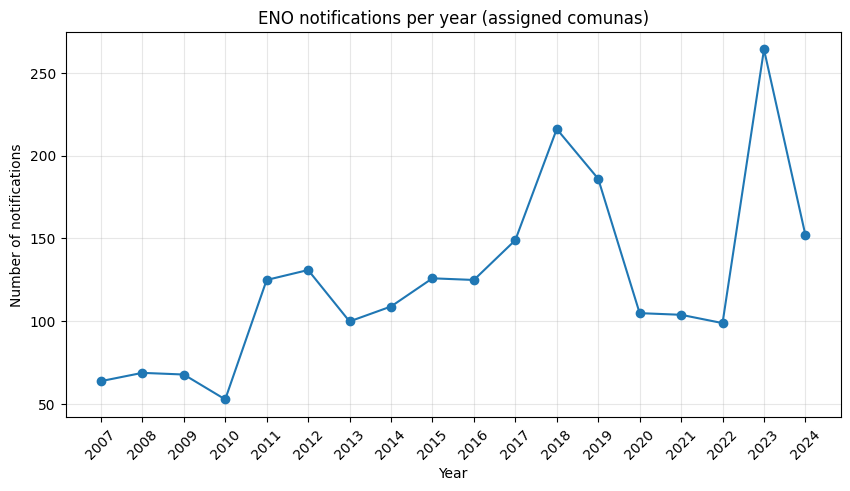

In [20]:
import matplotlib.pyplot as plt
year_total = eno_com["anho_notificacion"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(year_total.index, year_total.values, marker="o")

plt.title("ENO notifications per year (assigned comunas)")
plt.xlabel("Year")
plt.ylabel("Number of notifications")
plt.xticks(year_total.index, rotation=45)

plt.grid(True, alpha=0.3)
plt.show()

The total number of ENO notifications shows a general upward trend over time, although with clear fluctuations.

Between 2007 and 2017, notifications show an overall upward trend, with several fluctuations. A sharp increase occurs in 2018, after which the number of notifications declines. A drop is observed between 2020 and 2022, likely reflecting disruptions in health surveillance during the COVID-19 pandemic, with relatively low and stable levels in those years.

In 2023, notifications increase sharply, reaching the highest value in the series, before decreasing again in 2024. Overall, the pattern suggests long-term growth combined with short-term shocks.

#### A.1.2 Trend by nationality

In this section, the evolution of ENO notifications over time is analyzed by nationality, distinguishing between Chilean and foreign populations. Records with unknown nationality ("Desconocido") are excluded from this analysis.

The goal is to assess whether the relative contribution of foreign nationals to total notifications has changed over time.

First, the number and share of notifications are compared between Chilean and foreign groups. Then, notification rates per 10,000 inhabitants are computed using population data from Tarea 1 in order to account for differences in group size and allow a more meaningful comparison.

nacionalidad,Chile,Extranjero
anho_notificacion,,
2007,20,1
2008,21,0
2009,22,1
2010,23,0
2011,45,2


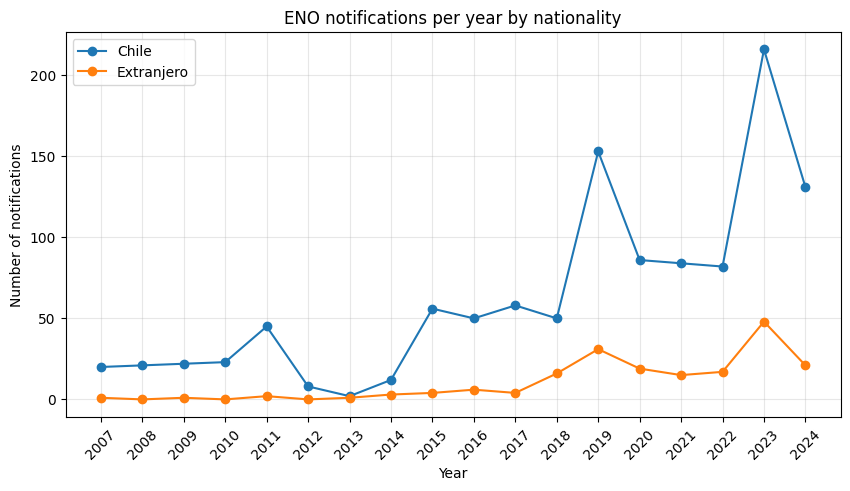


Share of notifications by nationality (%):


nacionalidad,Chile,Extranjero
anho_notificacion,,
2007,95.24,4.76
2008,100.00,0.00
2009,95.65,4.35
2010,100.00,0.00
2011,95.74,4.26
2012,100.00,0.00
2013,66.67,33.33
2014,80.00,20.00
2015,93.33,6.67


In [21]:
# Group by year and nationality (excluding "Desconocido")
year_nat = (
    eno_com_known_nat
    .groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

display(year_nat.head())

# Plot
plt.figure(figsize=(10, 5))

for col in year_nat.columns:
    plt.plot(year_nat.index, year_nat[col], marker="o", label=col)

plt.title("ENO notifications per year by nationality")
plt.xlabel("Year")
plt.ylabel("Number of notifications")

# Fix x-axis labels
plt.xticks(year_nat.index, rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Compute share of notifications by nationality (%)
year_nat_share = year_nat.div(year_nat.sum(axis=1), axis=0) * 100

print("\nShare of notifications by nationality (%):")
display(year_nat_share.round(2))

The number of ENO notifications for both Chilean and foreign populations follows a similar overall pattern over time, with increases and decreases occurring in the same periods.

However, the relative share of foreign-national notifications shows a noticeable change. In the early years, foreign participation is very low, often close to 0%. Starting around 2013, the share of foreign nationals increases and becomes more consistently present in the data.

This trend becomes more pronounced after 2018, where foreign nationals account for a higher proportion of notifications, reaching values above 15% in several years and peaking at around 24% in 2018.

Although Chilean nationals still represent the majority of notifications throughout the entire period, the growing share of foreign nationals suggests an increasing participation of this group in the observed disease burden over time.

Although the count and share of notifications provide a first view of differences by nationality, these comparisons do not account for the fact that the Chilean and foreign populations differ substantially in size.

To address this, crude notification rates per 10,000 inhabitants are computed below using the Chilean and foreign population totals from Tarea 1. This standardization allows for a more appropriate comparison of disease burden across groups.

Total Chilean population: 339,036.0
Total foreign population: 30,681.0

Notification rates per 10,000 by nationality:


,Chile,Extranjero
anho_notificacion,,
2007,0.59,0.33
2008,0.62,0.00
2009,0.65,0.33
2010,0.68,0.00
2011,1.33,0.65
2012,0.24,0.00
2013,0.06,0.33
2014,0.35,0.98
2015,1.65,1.30


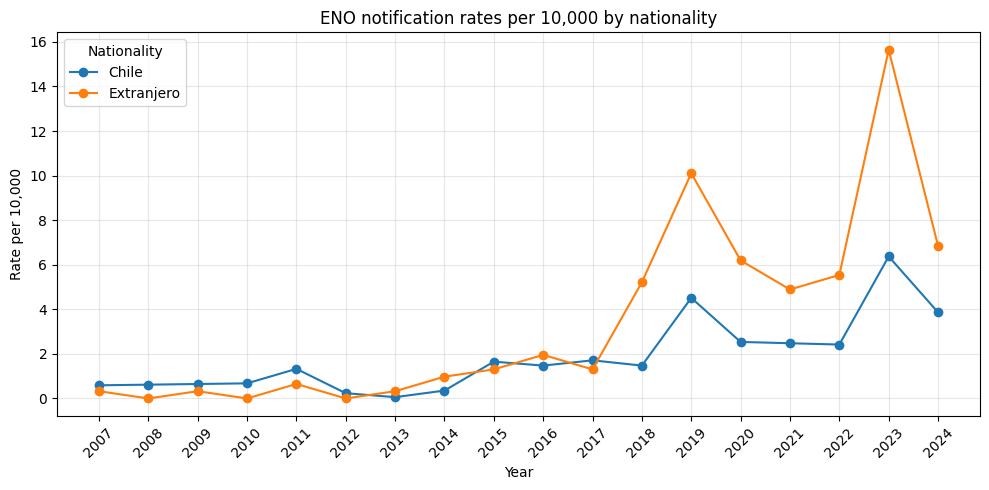

In [22]:
# Load Task 1 summary table
t1_summary = pd.read_csv("output/tarea1_comuna_summary.csv")

# Keep only the population columns needed
pop_nat = t1_summary[["codigo_comuna", "pop_chilean", "pop_foreign"]].copy()

# Compute total Chilean and foreign population across selected comunas
total_chilean_pop = pop_nat["pop_chilean"].sum()
total_foreign_pop = pop_nat["pop_foreign"].sum()

print(f"Total Chilean population: {total_chilean_pop:,}")
print(f"Total foreign population: {total_foreign_pop:,}")

year_nat = (
    eno_com_known_nat
    .groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

# Make sure both columns exist
if "Chile" not in year_nat.columns:
    year_nat["Chile"] = 0

if "Extranjero" not in year_nat.columns:
    year_nat["Extranjero"] = 0

# Compute rates per 10,000 inhabitants
year_nat_rate = pd.DataFrame(index=year_nat.index)
year_nat_rate["Chile"] = (year_nat["Chile"] / total_chilean_pop) * 10000
year_nat_rate["Extranjero"] = (year_nat["Extranjero"] / total_foreign_pop) * 10000

print("\nNotification rates per 10,000 by nationality:")
display(year_nat_rate.round(2))

# Plot rates
plt.figure(figsize=(10, 5))

plt.plot(year_nat_rate.index, year_nat_rate["Chile"], marker="o", label="Chile")
plt.plot(year_nat_rate.index, year_nat_rate["Extranjero"], marker="o", label="Extranjero")

plt.title("ENO notification rates per 10,000 by nationality")
plt.xlabel("Year")
plt.ylabel("Rate per 10,000")

plt.xticks(year_nat_rate.index, rotation=45)
plt.legend(title="Nationality")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Foreign population is much smaller than the Chilean population. Once population size is taken into account, the rate comparison shows a clearer pattern: foreign nationals tend to have higher notification rates than Chilean nationals in most recent years.

This difference becomes especially pronounced from 2018 onward. For example, in 2019 the notification rate is about 10.10 per 10,000 among foreign nationals compared to 4.51 among Chileans, and in 2023 the gap widens further to 15.64 versus 6.37 per 10,000.

Overall, while Chileans still dominate in absolute counts, the population-adjusted analysis suggests that the relative notification burden has been higher among foreign nationals in recent years.

### A.2 Disease Profiles

#### A.2.1 Top diseases overall

In this section, the most frequently notified diseases are identified using the `ENO` variable. The top 10 diseases across all years and selected comunas are presented using a horizontal bar chart.

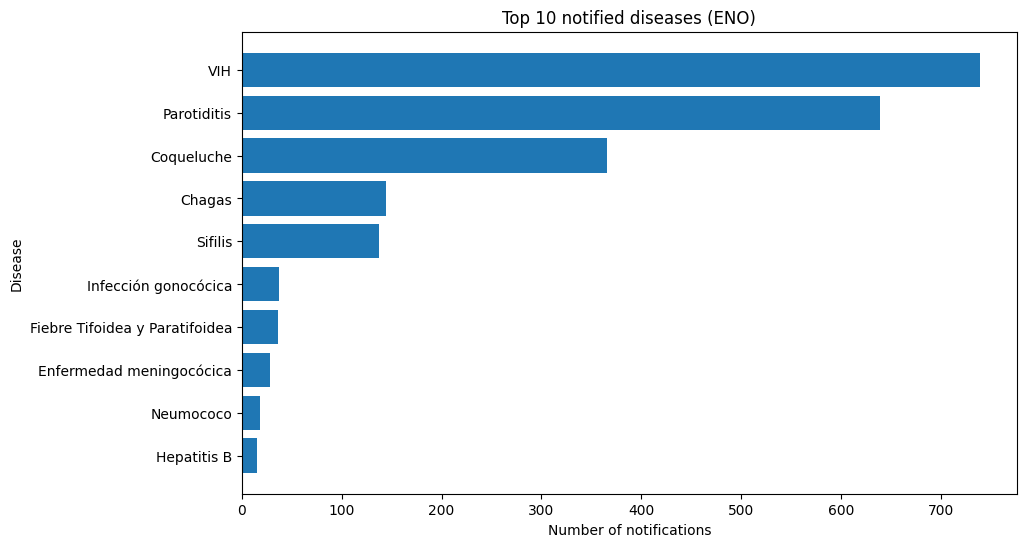


Top 10 diseases:


,ENO,count
0,VIH,739
1,Parotiditis,639
2,Coqueluche,366
3,Chagas,144
4,Sifilis,137
5,Infección gonocócica,37
6,Fiebre Tifoidea y Paratifoidea,36
7,Enfermedad meningocócica,28
8,Neumococo,18
9,Hepatitis B,15


In [23]:
# Get top 10 diseases
top10_diseases = eno_com["ENO"].value_counts().head(10)

# Sort for better visualization (smallest to largest)
top10_diseases = top10_diseases.sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top10_diseases.index, top10_diseases.values)

plt.title("Top 10 notified diseases (ENO)")
plt.xlabel("Number of notifications")
plt.ylabel("Disease")

plt.show()

# Display table (optional, but good for clarity)
top10_diseases_df = top10_diseases.sort_values(ascending=False).reset_index()
top10_diseases_df.columns = ["ENO", "count"]

print("\nTop 10 diseases:")
display(top10_diseases_df)

VIH clearly dominates the dataset, with 739 notifications, followed by Parotiditis (639) and Coqueluche (366).

After these three diseases, there is a sharp drop in frequency. Chagas (144) and Sifilis (137) still represent a relevant number of cases, but all remaining diseases have relatively low counts.

Overall, the results show that a few conditions account for most of the notification burden in the selected comunas, while the rest contribute marginally.

#### A.2.2 Disease profiles by nationality


In this section, the distribution of the top 5 most frequent diseases is analyzed by nationality, comparing Chilean and foreign populations. Records with unknown nationality ("Desconocido") are excluded.

The objective is to assess whether foreign nationals are over-represented in specific diseases relative to their share in the local population.

First, the composition of notifications is examined for each disease. Then, crude notification rates per 10,000 inhabitants are computed using population totals from Tarea 1, in order to account for the different sizes of the Chilean and foreign populations.


nacionalidad,Chile,Extranjero
ENO,,
Chagas,84.72,15.28
Coqueluche,100.00,0.00
Parotiditis,92.61,7.39
Sifilis,83.21,16.79
VIH,83.06,16.94


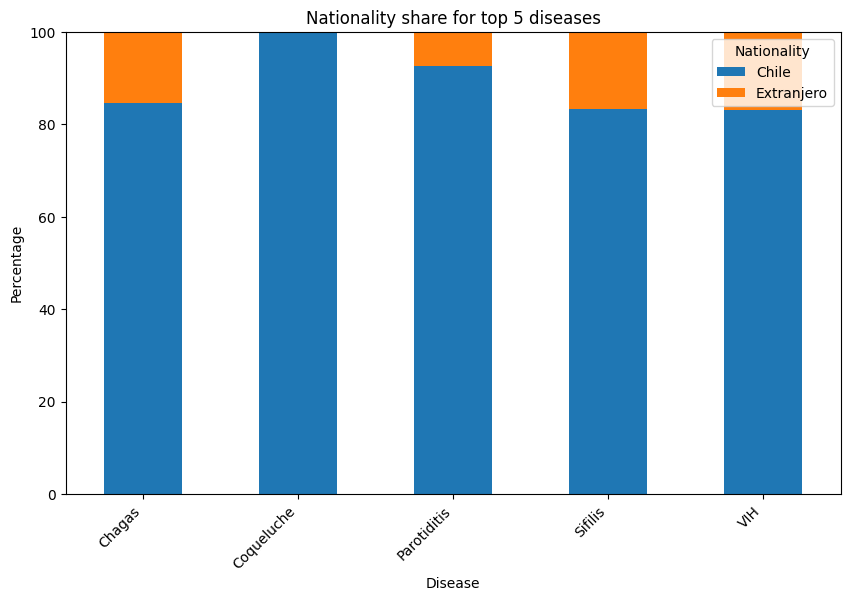

In [24]:
# Top 5 diseases (from full ENO, not filtered by nationality)
top5_diseases = eno_com["ENO"].value_counts().head(5).index.tolist()

# Filter dataset (excluding "Desconocido")
eno_top5_nat = eno_com_known_nat[
    eno_com_known_nat["ENO"].isin(top5_diseases)
].copy()

# Count by disease and nationality
disease_nat = (
    eno_top5_nat
    .groupby(["ENO", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage within each disease
disease_nat_pct = disease_nat.div(disease_nat.sum(axis=1), axis=0) * 100

display(disease_nat_pct.round(2))

# Plot stacked bar chart
disease_nat_pct.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Nationality share for top 5 diseases")
plt.xlabel("Disease")
plt.ylabel("Percentage")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")

plt.show()

The distribution of nationality across the top 5 diseases shows clear differences in the participation of foreign nationals.

For most diseases, Chilean nationals account for the majority of notifications. However, the share of foreign nationals is not negligible and varies across conditions. In particular, VIH (16.94%), Syphilis (16.79%), and Chagas (15.28%) show relatively high proportions of foreign notifications. In contrast, Parotiditis has a lower foreign share (7.39%), and Coqueluche is entirely composed of Chilean cases in this dataset.

When compared with the foreign-born population shares observed in the assigned comunas, these values suggest a potentially higher participation of foreign nationals in diseases such as VIH, Sifilis, and Chagas.

Although these percentages are useful to describe the composition of cases within each disease, they do not account for the fact that the foreign population is much smaller than the Chilean population.

To make the comparison more meaningful, crude notification rates per 10,000 inhabitants are computed below for each disease and nationality group using population totals from Tarea 1.

Total Chilean population: 339,036.0
Total foreign population: 30,681.0
Notification rates per 10,000 by disease and nationality:


,Chile,Extranjero
ENO,,
Chagas,3.60,7.17
Coqueluche,0.91,0.00
Parotiditis,6.28,5.54
Sifilis,3.36,7.50
VIH,15.19,34.22


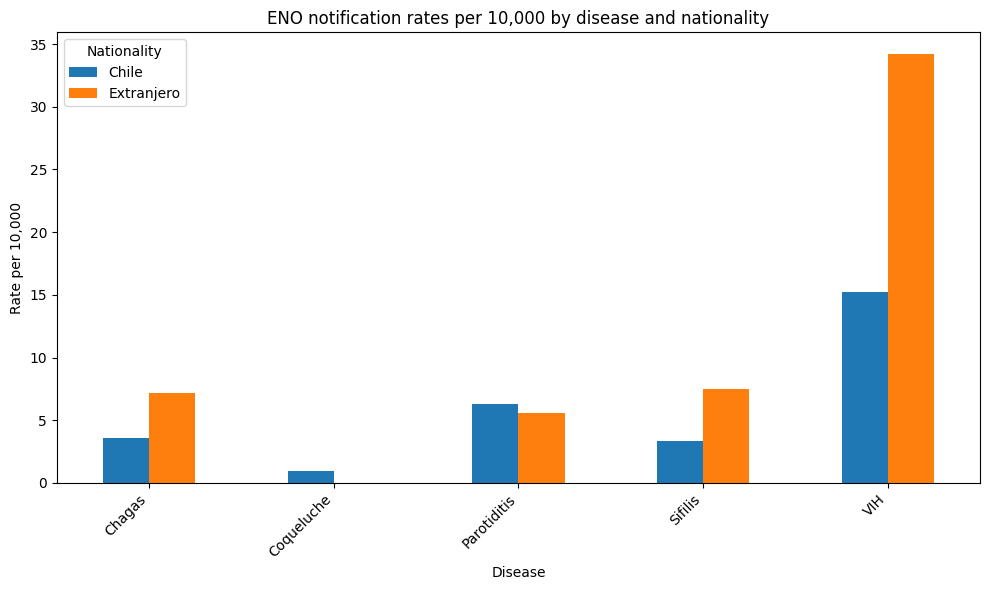

In [39]:
# Load Task 1 summary table
t1_summary = pd.read_csv("output/tarea1_comuna_summary.csv")

# Compute total Chilean and foreign population across selected comunas
total_chilean_pop = t1_summary["pop_chilean"].sum()
total_foreign_pop = t1_summary["pop_foreign"].sum()

print(f"Total Chilean population: {total_chilean_pop:,}")
print(f"Total foreign population: {total_foreign_pop:,}")

# Make sure both nationality columns exist
if "Chile" not in disease_nat.columns:
    disease_nat["Chile"] = 0

if "Extranjero" not in disease_nat.columns:
    disease_nat["Extranjero"] = 0

# Compute crude notification rates per 10,000 inhabitants
disease_nat_rate = pd.DataFrame(index=disease_nat.index)
disease_nat_rate["Chile"] = (disease_nat["Chile"] / total_chilean_pop) * 10000
disease_nat_rate["Extranjero"] = (disease_nat["Extranjero"] / total_foreign_pop) * 10000

print("Notification rates per 10,000 by disease and nationality:")
display(disease_nat_rate.round(2))

# Plot grouped bar chart
disease_nat_rate.plot(kind="bar", figsize=(10, 6))

plt.title("ENO notification rates per 10,000 by disease and nationality")
plt.xlabel("Disease")
plt.ylabel("Rate per 10,000")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")
plt.tight_layout()

plt.show()

When population size is taken into account, notification rates provide a clearer comparison of disease burden across groups. The results indicate that diseases such as VIH, Sifilis, and Chagas exhibit higher notification rates among foreign nationals than among Chileans, suggesting a relatively higher burden in the foreign population. This pattern is particularly pronounced for VIH, where the rate among foreign nationals is substantially higher. In contrast, Parotiditis shows a lower relative burden among foreign nationals, while Coqueluche remains entirely concentrated among Chileans in the observed data. Overall, although Chilean nationals dominate in absolute counts, the rate-based analysis reveals that certain diseases disproportionately affect the foreign population.

#### A.2.3 Age-group distribution for the top disease

In this section, the age-group distribution of the most frequently notified disease is analyzed. The distribution is split by nationality (Chilean vs. foreign), excluding records with unknown nationality.

The objective is to identify whether there are differences in the age profile of this disease between the two populations.

Top disease: VIH


nacionalidad,Chile,Extranjero
grupo_edad,,
***,3,2
00-04,5,1
05-09,1,0
10-14,2,0
15-19,18,2
20-24,70,7
25-29,109,18
30-34,87,24
35-39,53,24


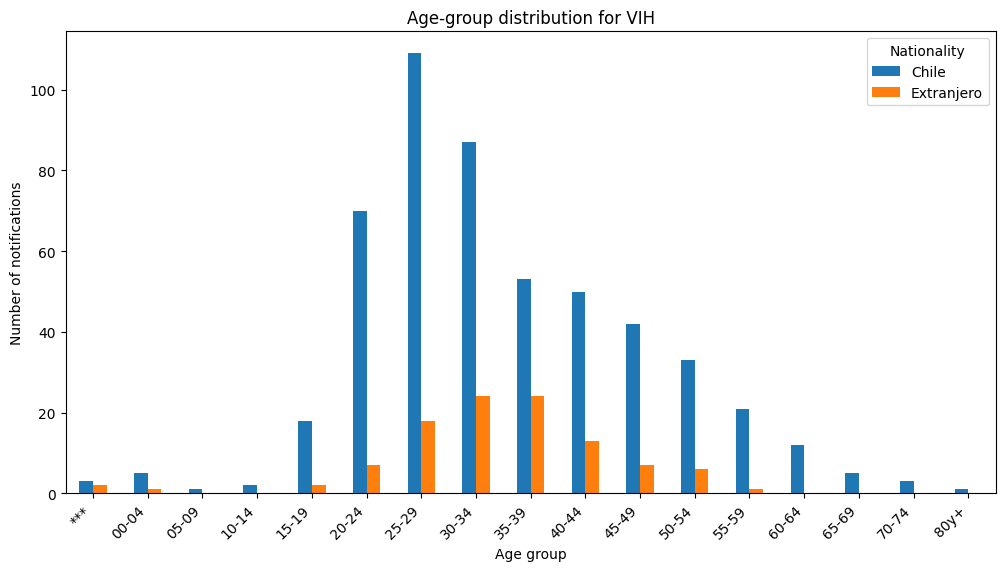

In [26]:
# Identify top disease
top_disease = eno_com["ENO"].value_counts().idxmax()
print(f"Top disease: {top_disease}")

# Filter dataset (excluding "Desconocido")
eno_top = eno_com_known_nat[
    eno_com_known_nat["ENO"] == top_disease
].copy()

# Group by age and nationality
age_dist = (
    eno_top
    .groupby(["grupo_edad", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

display(age_dist)

# Plot
age_dist.plot(kind="bar", figsize=(12, 6))

plt.title(f"Age-group distribution for {top_disease}")
plt.xlabel("Age group")
plt.ylabel("Number of notifications")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")

plt.show()

A small number of records with undefined age group ("*") are present but do not affect the overall pattern.

The age distribution of VIH notifications is concentrated in young and middle-aged adults for both Chilean and foreign populations.

In both groups, the highest number of cases occurs between ages 25–34, with a clear peak in the 25–29 age group. After this range, the number of notifications gradually declines with age.

The overall shape of the distribution is similar for Chilean and foreign populations, indicating a comparable age profile. However, foreign nationals show a relatively higher presence in the 30–39 age range compared to younger groups, suggesting a slightly more concentrated distribution in working-age adults.

Overall, VIH notifications are strongly concentrated in the adult population, with very low number of notifications in children and older age groups.

### A.3 Spatial View

#### A.3.1 Notification counts by comuna

In this section, the total number of ENO notifications is computed for each selected comuna. Additionally, a crude notification rate per 10,000 inhabitants is calculated using population data from Tarea 1.

This allows for a comparison of both absolute notification counts and population-adjusted rates across comunas.

,codigo_comuna_residencia,eno_total,nombre_comuna,codigo_comuna,pop_total,eno_rate_per_10k
0,13115,630,Lo Barnechea,13115.0,112620.0,55.940330
1,13128,1064,Renca,13128.0,143622.0,74.083358
2,13402,551,Buin,13402.0,116969.0,47.106498


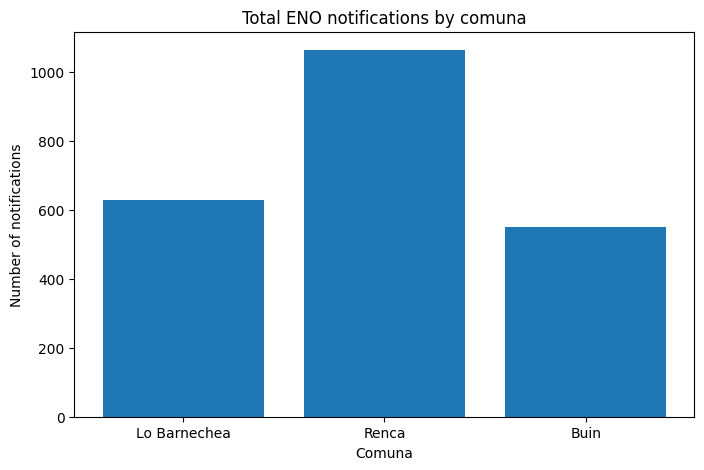

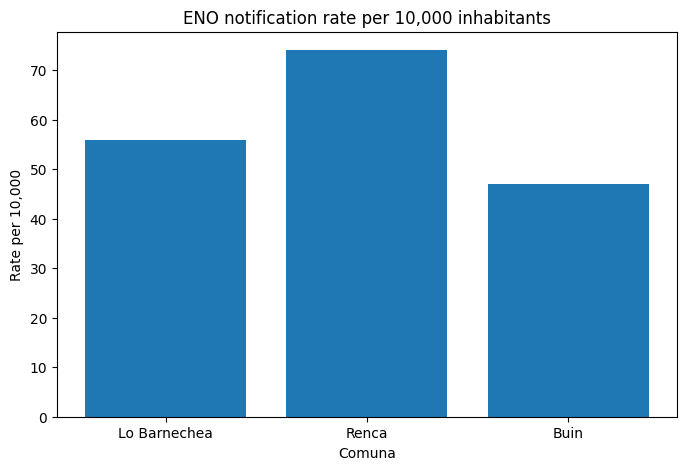

In [27]:
# Convert comuna code to numeric
eno_com["codigo_comuna_residencia"] = eno_com["codigo_comuna_residencia"].astype(int)

# Total notifications by comuna
eno_by_comuna = (
    eno_com.groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="eno_total")
)

# Map comuna names
comuna_map = {
    13128: "Renca",
    13115: "Lo Barnechea",
    13402: "Buin"
}

eno_by_comuna["nombre_comuna"] = eno_by_comuna["codigo_comuna_residencia"].map(comuna_map)

# Load Tarea 1 summary (if not already loaded)
t1_summary = pd.read_csv("output/tarea1_comuna_summary.csv")

# Merge population data
eno_by_comuna = eno_by_comuna.merge(
    t1_summary[["codigo_comuna", "pop_total"]],
    left_on="codigo_comuna_residencia",
    right_on="codigo_comuna",
    how="left"
)

# Compute rate per 10,000 inhabitants
eno_by_comuna["eno_rate_per_10k"] = (
    eno_by_comuna["eno_total"] / eno_by_comuna["pop_total"] * 10000
)

display(eno_by_comuna)

# -------------------------
# Plot 1: total notifications
# -------------------------
plt.figure(figsize=(8, 5))
plt.bar(eno_by_comuna["nombre_comuna"], eno_by_comuna["eno_total"])

plt.title("Total ENO notifications by comuna")
plt.xlabel("Comuna")
plt.ylabel("Number of notifications")

plt.show()

# -------------------------
# Plot 2: rate per 10,000
# -------------------------
plt.figure(figsize=(8, 5))
plt.bar(eno_by_comuna["nombre_comuna"], eno_by_comuna["eno_rate_per_10k"])

plt.title("ENO notification rate per 10,000 inhabitants")
plt.xlabel("Comuna")
plt.ylabel("Rate per 10,000")

plt.show()

The total number of ENO notifications varies across comunas. Renca records the highest number of notifications (1,064), followed by Lo Barnechea (630) and Buin (551).

When adjusting for population size, the pattern remains consistent. Renca also shows the highest notification rate, with approximately 74 notifications per 10,000 inhabitants, compared to around 56 in Lo Barnechea and 47 in Buin.

It is important to note that these values are underestimates of the true number of notifications, as a substantial share of the ENO dataset has anonymized comuna information ("*****") and could not be assigned to specific territories.

### A.4 Comuna-Level ENO Summary Table

In this section, a comuna-level summary table is constructed using the ENO dataset. The table includes total notifications, nationality-specific counts, the three most frequent diseases, and a crude notification rate per 10,000 inhabitants based on population totals from Tarea 1.

This summary table serves as the main ENO output for the selected comunas and will be useful for later integration with other datasets.

In [28]:
import os

# Make sure output folder exists
os.makedirs("output", exist_ok=True)

# Function to build one summary row per comuna
def build_eno_summary(group):
    codigo = group.name
    
    # Get comuna name from Tarea 1 summary
    nombre = t1_summary.loc[
        t1_summary["codigo_comuna"] == codigo, "nombre_comuna"
    ].iloc[0]
    
    # Basic counts
    eno_total = len(group)
    eno_chilean = (group["nacionalidad"] == "Chile").sum()
    eno_foreign = (group["nacionalidad"] == "Extranjero").sum()
    eno_desconocido = (group["nacionalidad"] == "Desconocido").sum()
    
    # Top 3 diseases
    top3 = group["ENO"].value_counts().head(3).index.tolist()
    eno_top3_diseases = ", ".join(top3)
    
    # Population from Tarea 1
    pop_total = t1_summary.loc[
        t1_summary["codigo_comuna"] == codigo, "pop_total"
    ].iloc[0]
    
    # Rate per 10,000
    eno_rate_per_10k = (eno_total / pop_total) * 10000 if pop_total > 0 else 0
    
    return pd.Series({
        "codigo_comuna": codigo,
        "nombre_comuna": nombre,
        "eno_total": eno_total,
        "eno_chilean": eno_chilean,
        "eno_foreign": eno_foreign,
        "eno_desconocido": eno_desconocido,
        "eno_top3_diseases": eno_top3_diseases,
        "eno_rate_per_10k": eno_rate_per_10k
    })

# Build summary table
eno_summary = (
    eno_com.groupby("codigo_comuna_residencia")
    .apply(build_eno_summary)
    .reset_index(drop=True)
)

# Optional: round numeric columns
eno_summary["eno_rate_per_10k"] = eno_summary["eno_rate_per_10k"].round(2)

# Display final table
print("FINAL ENO SUMMARY TABLE")
display(eno_summary)

# Save as CSV
eno_summary.to_csv("output/tarea2_eno_summary.csv", index=False)

print("File saved as: output/tarea2_eno_summary.csv")

FINAL ENO SUMMARY TABLE


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13115,Lo Barnechea,630,278,42,310,"Parotiditis, Coqueluche, VIH",55.94
1,13128,Renca,1064,590,113,361,"VIH, Parotiditis, Coqueluche",74.08
2,13402,Buin,551,251,34,266,"Parotiditis, VIH, Coqueluche",47.11


File saved as: output/tarea2_eno_summary.csv


The comuna-level ENO summary table shows clear differences in both the total number of notifications and their composition across comunas.

Renca has the highest number of notifications (1,064), followed by Lo Barnechea (630) and Buin (551). This pattern is consistent with the results observed in the previous section.

In terms of nationality, a substantial share of notifications in all comunas corresponds to cases with unknown nationality. Among known cases, Chilean nationals represent the majority, although foreign nationals account for a non-negligible proportion.

The top three diseases are similar across comunas, with Parotiditis, VIH, and Coqueluche consistently appearing among the most frequent conditions.

When adjusting for population size, Renca also shows the highest notification rate (74.08 per 10,000 inhabitants), followed by Lo Barnechea (55.94) and Buin (47.11), indicating a higher relative disease burden in Renca.

As noted previously, these figures should be interpreted as underestimates, since a large fraction of ENO records has anonymized comuna information and could not be assigned to specific comunas.

## Part B: GRD – Hospital Discharges 

### B.0 Data Loading & Cleaning

#### B.0.1 Load GRD files for 2022–2024

In this section, the GRD discharge records for 2022, 2023, and 2024 are loaded from compressed ZIP files. Since the internal structure of the files is not fully consistent across years, each dataset is imported separately to ensure correct parsing.

In particular, differences were observed both in the internal filename (for 2022) and in file encoding. To address this, a robust loading strategy was implemented: each file was first attempted using UTF-16 encoding, and if that failed, it was read using Latin-1 encoding.

Only the variables required for the analysis were selected. This is important given the large size of the GRD files, as it reduces memory usage and improves computational efficiency.

In [29]:
import zipfile

grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

def load_grd_safe(zip_path, txt_name, year):
    with zipfile.ZipFile(zip_path) as z:
        with z.open(txt_name) as f:
            
            # intento 1: utf-16
            try:
                df = pd.read_csv(
                    f,
                    sep="|",
                    encoding="utf-16",
                    usecols=grd_cols,
                    low_memory=False
                )
                print(f"{year}: loaded with utf-16")
            
            # intento 2: latin-1
            except Exception:
                f.seek(0) 
                df = pd.read_csv(
                    f,
                    sep="|",
                    encoding="latin-1",
                    usecols=grd_cols,
                    low_memory=False
                )
                print(f"{year}: loaded with latin-1")

    df["year"] = year
    return df

# -------------------------
# Load each year
# -------------------------
grd_2022 = load_grd_safe(
    "GRD_PUBLICO_2022.zip",
    "GRD_PUBLICO_EXTERNO_2022.txt",
    2022
)

grd_2023 = load_grd_safe(
    "GRD_PUBLICO_2023.zip",
    "GRD_PUBLICO_2023.txt",
    2023
)

grd_2024 = load_grd_safe(
    "GRD_PUBLICO_2024.zip",
    "GRD_PUBLICO_2024.txt",
    2024
)

# -------------------------
# Combine
# -------------------------
grd = pd.concat([grd_2022, grd_2023, grd_2024], ignore_index=True)

print("\n=== GRD DATA LOADED ===")
print(f"2022 rows: {len(grd_2022):,}")
print(f"2023 rows: {len(grd_2023):,}")
print(f"2024 rows: {len(grd_2024):,}")
print(f"Total discharges (2022–2024): {len(grd):,}")

print("\nShape:")
print(grd.shape)

print("\nInfo:")
grd.info()

display(grd.head())

2022: loaded with utf-16
2023: loaded with utf-16
2024: loaded with latin-1

=== GRD DATA LOADED ===
2022 rows: 932,840
2023 rows: 1,039,587
2024 rows: 1,085,813
Total discharges (2022–2024): 3,058,240

Shape:
(3058240, 15)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3058240 entries, 0 to 3058239
Data columns (total 15 columns):
 #   Column               Dtype
---  ------               -----
 0   SEXO                 str  
 1   FECHA_NACIMIENTO     str  
 2   COMUNA               str  
 3   NACIONALIDAD         str  
 4   TIPO_INGRESO         str  
 5   ESPECIALIDAD_MEDICA  str  
 6   FECHA_INGRESO        str  
 7   FECHAALTA            str  
 8   TIPOALTA             str  
 9   DIAGNOSTICO1         str  
 10  DIAGNOSTICO2         str  
 11  IR_29301_COD_GRD     str  
 12  IR_29301_SEVERIDAD   str  
 13  IR_29301_MORTALIDAD  str  
 14  year                 int64
dtypes: int64(1), str(14)
memory usage: 662.2 MB


,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÍA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÍA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


The GRD discharge records for 2022, 2023, and 2024 were successfully loaded from the compressed ZIP files.

A total of 932,840 discharges were loaded for 2022, 1,039,587 for 2023, and 1,085,813 for 2024, resulting in a combined dataset of 3,058,240 hospital discharge records. The final dataset contains 15 variables, including demographic information, admission and discharge details, and diagnostic codes.

This unified dataset serves as the basis for the subsequent analysis of hospitalization patterns across the selected comunas.

#### B.0.2 Filter to your comunas

In the GRD dataset, comunas are identified using uppercase text names rather than numeric codes. To filter the dataset to the assigned comunas, a mapping is required between the comuna codes used in Tarea 1 and the corresponding comuna names.

To ensure a correct match, comuna names are standardized by converting them to uppercase and removing extra spaces. The filtered dataset includes only discharges corresponding to the selected comunas.

Finally, the number of discharges is reported both in total and by year for the selected comunas.

In [30]:

# --- Step 0: Load Tarea 1 summary table ---
t1_summary = pd.read_csv("output/tarea1_comuna_summary.csv")

# --- Step 1: Build mapping from comuna code to name ---
comuna_map = t1_summary[["codigo_comuna", "nombre_comuna"]].drop_duplicates().copy()

# Standardize comuna names to match GRD format
comuna_map["COMUNA"] = (
    comuna_map["nombre_comuna"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# List of target comunas
my_comuna_names = comuna_map["COMUNA"].tolist()

print("Target comunas:")
print(my_comuna_names)

# --- Step 2: Standardize GRD comuna names ---
grd["COMUNA_clean"] = (
    grd["COMUNA"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# --- Step 3: Filter GRD to selected comunas ---
grd_com = grd[grd["COMUNA_clean"].isin(my_comuna_names)].copy()

print("\n=== FILTERED DATA ===")
print(f"Discharges in my comunas: {len(grd_com):,}")

# --- Step 4: Discharges per year ---
discharges_by_year = (
    grd_com["year"]
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="n_discharges")
)

print("\nDischarges per year:")
display(discharges_by_year)

# --- Step 5: Discharges per comuna ---
discharges_by_comuna = (
    grd_com["COMUNA_clean"]
    .value_counts()
    .rename_axis("COMUNA")
    .reset_index(name="n_discharges")
)

print("\nDischarges per comuna:")
display(discharges_by_comuna)

Target comunas:
['LO BARNECHEA', 'RENCA', 'BUIN']

=== FILTERED DATA ===
Discharges in my comunas: 48,088

Discharges per year:


,year,n_discharges
0,2022,14387
1,2023,16757
2,2024,16944



Discharges per comuna:


,COMUNA,n_discharges
0,RENCA,25748
1,BUIN,15457
2,LO BARNECHEA,6883


The GRD dataset was successfully filtered to the assigned comunas (Lo Barnechea, Renca, and Buin) by mapping comuna names from the Tarea 1 summary table to the uppercase text format used in the GRD data.

A total of 48,088 hospital discharges were identified across the selected comunas for the period 2022–2024. The number of discharges increased over time, with 14,387 in 2022, 16,757 in 2023, and 16,944 in 2024, indicating a gradual rise in hospital activity.

Across comunas, Renca accounts for the largest number of discharges (25,748), followed by Buin (15,457) and Lo Barnechea (6,883). 

#### B.0.3 Compute length of stay

The GRD dataset does not include an explicit variable for length of stay (LOS), so it must be computed from the admission and discharge dates. Length of stay is defined as the number of days between the admission date (`FECHA_INGRESO`) and the discharge date (`FECHAALTA`).

After computing LOS, its distribution is summarized using descriptive statistics. Records with negative LOS values are treated as data errors and removed from the dataset, while same-day discharges (LOS = 0) are considered valid.

In [31]:
# --- Step 1: Convert date columns to datetime ---
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors="coerce")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors="coerce")

# --- Step 2: Compute length of stay (LOS) in days ---
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# --- Step 3: Describe LOS distribution before cleaning ---
print("=== LOS distribution (before cleaning) ===")
display(grd_com["los"].describe())

# Extract required statistics
los_mean = grd_com["los"].mean()
los_median = grd_com["los"].median()
los_min = grd_com["los"].min()
los_max = grd_com["los"].max()

print(f"Mean LOS: {los_mean:.2f}")
print(f"Median LOS: {los_median}")
print(f"Min LOS: {los_min}")
print(f"Max LOS: {los_max}")

# --- Step 4: Identify and remove negative LOS values ---
neg_los_count = (grd_com["los"] < 0).sum()
print(f"\nRows with LOS < 0 (to be removed): {neg_los_count:,}")

# Filter out negative LOS values
grd_com = grd_com[grd_com["los"].isna() | (grd_com["los"] >= 0)].copy()

# --- Step 5: Describe LOS after cleaning ---
print("\n=== LOS distribution (after cleaning) ===")
display(grd_com["los"].describe())

=== LOS distribution (before cleaning) ===


count    31330.000000
mean         5.953048
std         12.504238
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        365.000000
Name: los, dtype: float64

Mean LOS: 5.95
Median LOS: 3.0
Min LOS: 0.0
Max LOS: 365.0

Rows with LOS < 0 (to be removed): 0

=== LOS distribution (after cleaning) ===


count    31330.000000
mean         5.953048
std         12.504238
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        365.000000
Name: los, dtype: float64

The distribution of LOS is based on 31,330 observations, which is lower than the total number of discharges (48,088). This difference is explained by missing or invalid date values, which resulted in undefined LOS for a subset of records. These cases were retained in the dataset but excluded from the LOS distribution analysis.

The distribution of LOS shows a mean of 5.95 days and a median of 3 days, with values ranging from 0 to 365 days.

No records with negative LOS values were found, indicating that there are no evident data inconsistencies in the date variables. Same-day discharges (LOS = 0) were retained as valid observations.

The distribution suggests that most hospitalizations are relatively short, with the majority of stays concentrated within a few days, although a small number of cases extend to much longer durations.

#### B.0.4 Create a nationality grouping

The `NACIONALIDAD` variable in the GRD dataset contains country names rather than a simple binary classification. To facilitate comparison between broad population groups, this variable is recoded into two categories: `Chilean` for patients whose nationality is reported as `CHILE`, and `Foreign` for all other nationalities.

Before creating this grouping, the nationality values are standardized to ensure a consistent comparison. The resulting distribution is then reported and will be used in the following analyses of diagnoses, length of stay, severity, and discharge outcomes.

In [32]:
import numpy as np

# Standardize nationality values before grouping
grd_com["NACIONALIDAD_clean"] = (
    grd_com["NACIONALIDAD"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Create binary nationality grouping
grd_com["nat_group"] = np.where(
    grd_com["NACIONALIDAD_clean"] == "CHILE",
    "Chilean",
    "Foreign"
)

print("Nationality grouping:")
nat_dist = (
    grd_com["nat_group"]
    .value_counts()
    .rename_axis("nat_group")
    .reset_index(name="count")
)

nat_dist["share"] = nat_dist["count"] / nat_dist["count"].sum()

display(nat_dist)

Nationality grouping:


,nat_group,count,share
0,Chilean,44875,0.933185
1,Foreign,3213,0.066815


The resulting distribution shows that 93.3% of hospital discharges correspond to Chilean patients (44,875 cases), while 6.7% correspond to foreign patients (3,213 cases). This distribution provides a basis for comparing hospitalization patterns across nationality groups in the following analyses.

#### B.0.5 Join diagnoses to CIE-10

To make the GRD diagnoses interpretable, the principal diagnosis code (`DIAGNOSTICO1`) is linked to the ICD-10 lookup table. This join allows each hospital discharge record to be associated with a human-readable diagnosis description and a broader diagnostic chapter.

Before merging, diagnosis codes are standardized to ensure a consistent match between both datasets. After the join, the number of unmatched rows is reported as a data quality check, since some diagnosis codes may not appear in the lookup table.

In [33]:
# --- Step 1: Load ICD-10 lookup table ---
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

# --- Step 2: Keep only the columns needed for the merge ---
cie10_lookup = (
    cie10[["Código", "Descripción", "Capítulo"]]
    .drop_duplicates(subset="Código")
    .copy()
)

# --- Step 3: Standardize diagnosis codes in both datasets ---
grd_com["DIAGNOSTICO1_clean"] = (
    grd_com["DIAGNOSTICO1"]
    .astype(str)
    .str.upper()
    .str.strip()
)

cie10_lookup["Codigo_clean"] = (
    cie10_lookup["Código"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# --- Step 4: Merge GRD with ICD-10 lookup ---
grd_com = grd_com.merge(
    cie10_lookup[["Codigo_clean", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1_clean",
    right_on="Codigo_clean",
    how="left"
)

# --- Step 5: Report unmatched rows ---
failed_matches = grd_com["Capítulo"].isna().sum()
failed_share = failed_matches / len(grd_com)

print("=== ICD-10 JOIN RESULTS ===")
print(f"Rows with no chapter match: {failed_matches:,}")
print(f"Share unmatched: {failed_share:.2%}")

# --- Step 6: Preview merged columns ---
display(
    grd_com[["DIAGNOSTICO1", "DIAGNOSTICO1_clean", "Descripción", "Capítulo"]]
    .head(10)
)

=== ICD-10 JOIN RESULTS ===
Rows with no chapter match: 4
Share unmatched: 0.01%


,DIAGNOSTICO1,DIAGNOSTICO1_clean,Descripción,Capítulo
0,O24.4,O24.4,Diabetes mellitus que se origina con el embarazo,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
1,O23.0,O23.0,Infección del riñón en el embarazo,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
2,T79.6,T79.6,Isquemia traumática de músculo,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ..."
3,K80.1,K80.1,Cálculo de la vesícula biliar con otra colecis...,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...
4,J44.1,J44.1,Enfermedad pulmonar obstructiva crónica con ex...,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...
5,P22.1,P22.1,Taquipnea transitoria del recién nacido,Cap.16 CIERTAS AFECCIONES ORIGINADAS EN EL PE...
6,S42.00,S42.00,"Fractura de la clavícula, cerrada","Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ..."
7,O99.5,O99.5,Enfermedades del sistema respiratorio que comp...,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
8,S12.20,S12.20,Fractura de otras vértebras cervicales especif...,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ..."
9,T46.5,T46.5,"Otras drogas antihipertensivas, no clasificada...","Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ..."


The principal diagnosis code (`DIAGNOSTICO1`) was successfully linked to the ICD-10 lookup table, allowing each hospital discharge record to be associated with a human-readable diagnosis description and a broader diagnostic chapter.

After standardizing diagnosis codes and performing the merge, only 4 rows failed to match an ICD-10 chapter, representing 0.01% of the filtered GRD dataset. These unmatched cases are negligible and likely reflect minor coding inconsistencies or rare diagnosis codes not included in the lookup table.


### B.1 Diagnostic Profile

#### B.1.1 Top diagnostic chapters

To understand the main causes of hospitalization, discharges are grouped by ICD-10 diagnostic chapter (`Capítulo`). This allows the identification of broad disease categories that dominate hospitalizations in the selected comunas.

The top 10 chapters are presented using a horizontal bar chart to facilitate comparison across categories.

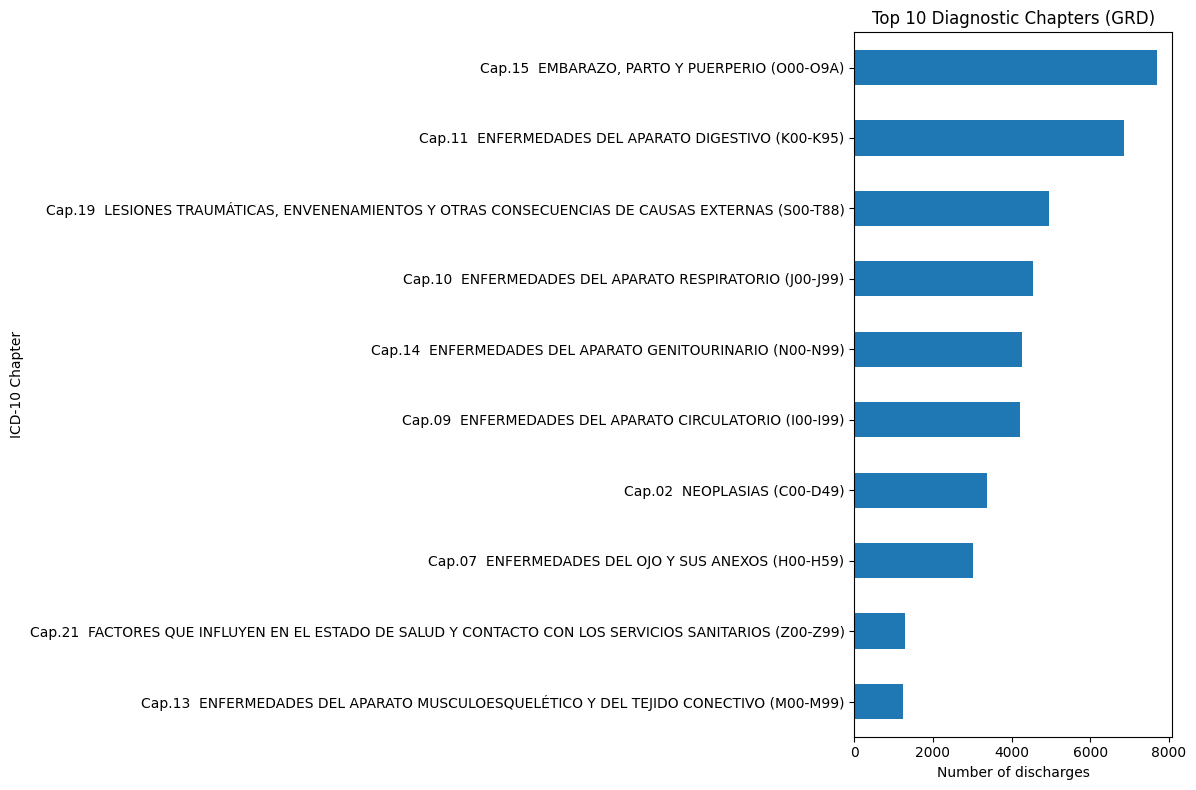

In [34]:
# --- Step 1: Count discharges by ICD-10 chapter ---
chapters = (
    grd_com["Capítulo"]
    .value_counts()
    .head(10)
)

# --- Step 2: Plot horizontal bar chart ---
plt.figure(figsize=(12, 8))

chapters.sort_values().plot(kind="barh")

plt.xlabel("Number of discharges")
plt.ylabel("ICD-10 Chapter")
plt.title("Top 10 Diagnostic Chapters (GRD)")

plt.tight_layout()
plt.show()

The distribution of hospital discharges by ICD-10 diagnostic chapter shows that a small number of broad disease categories account for a large share of hospitalizations in the selected comunas.

The most frequent category is Chapter 15 (Pregnancy, childbirth, and the puerperium), indicating that obstetric-related hospitalizations represent a major component of healthcare demand. This is followed by Chapter 11 (Diseases of the digestive system) and Chapter 19 (Injuries and external causes), suggesting that both common medical conditions and trauma-related events contribute significantly to hospital admissions.

Other important categories include respiratory (Chapter 10), genitourinary (Chapter 14), and circulatory diseases (Chapter 9), which are typically associated with both acute and chronic conditions.


#### B.1.2 Top specific diagnoses

To further understand the drivers of hospitalizations, discharges are grouped by specific ICD-10 diagnosis (`Descripción`). This provides a more detailed view compared to the broader diagnostic chapters.

The top 15 most frequent diagnoses are presented using a horizontal bar chart to highlight the most common conditions leading to hospital admissions in the selected comunas.

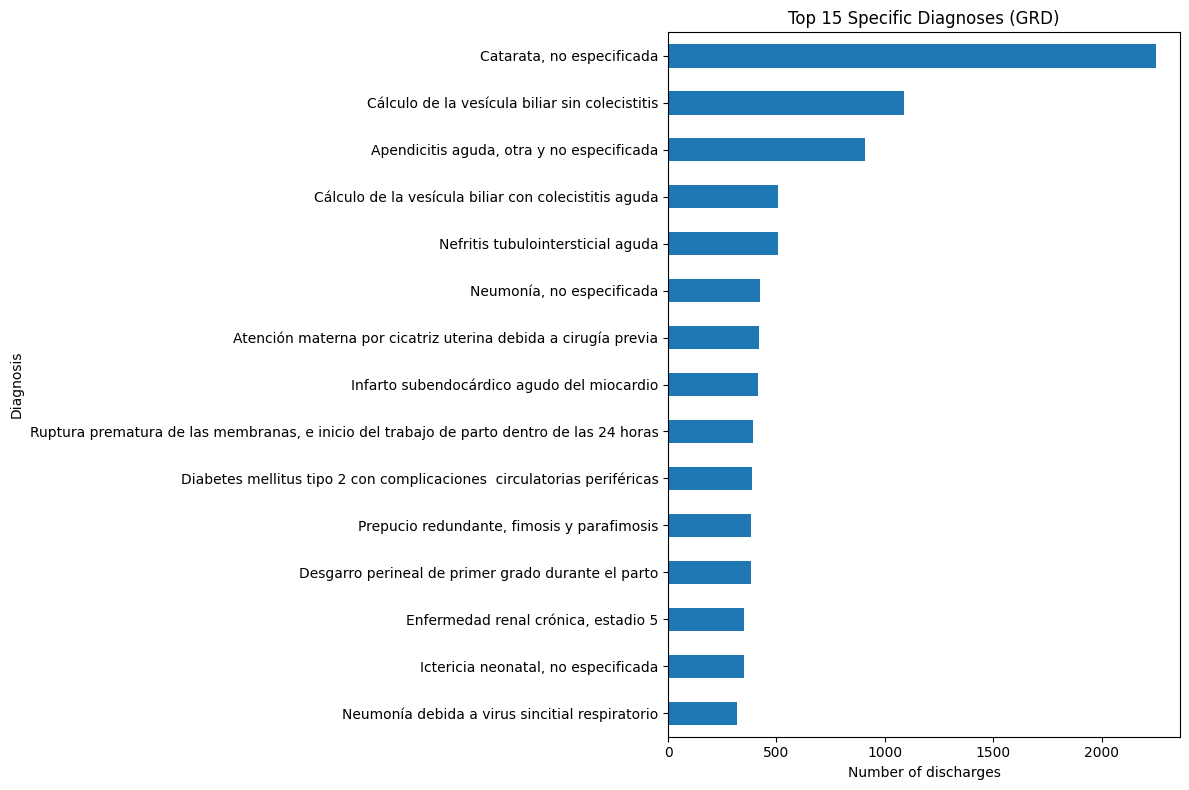

In [35]:
# --- Step 1: Count discharges by specific diagnosis ---
top_diagnoses = (
    grd_com["Descripción"]
    .dropna()
    .value_counts()
    .head(15)
)

# --- Step 2: Plot horizontal bar chart ---
plt.figure(figsize=(12, 8))

top_diagnoses.sort_values().plot(kind="barh")

plt.xlabel("Number of discharges")
plt.ylabel("Diagnosis")
plt.title("Top 15 Specific Diagnoses (GRD)")

plt.tight_layout()
plt.show()

The analysis of specific diagnoses shows that a relatively small number of conditions account for a large share of hospital discharges.

The most frequent diagnosis is cataract (unspecified), indicating a high volume of planned surgical procedures, particularly related to aging populations. This is followed by conditions such as gallbladder disease and acute appendicitis, which are common causes of surgical hospitalizations.

Several diagnoses related to pregnancy and childbirth also appear among the most frequent, including maternal care and complications during labor, reinforcing the importance of obstetric-related hospitalizations identified in the previous section.

Additionally, conditions such as pneumonia, myocardial infarction, and diabetes complications highlight the role of both acute and chronic diseases in driving hospital admissions.

Overall, the results suggest that hospitalizations are driven by a combination of elective procedures, common surgical conditions, maternal care, and chronic disease complications, providing a comprehensive view of healthcare demand in the selected comunas.

#### B.1.3 Diagnostic chapters by nationality


To compare hospitalization patterns across nationality groups, the top 5 ICD-10 diagnostic chapters are analyzed by nationality. For each chapter, the share of discharges corresponding to Chilean and foreign patients is computed.

The results are presented using a grouped bar chart, allowing for a clear comparison of the relative participation of each group across major diagnostic categories.

This analysis is then contextualized using the proportion of foreign-born population from Tarea 1 to identify whether certain diagnostic categories show over-representation of foreign patients.

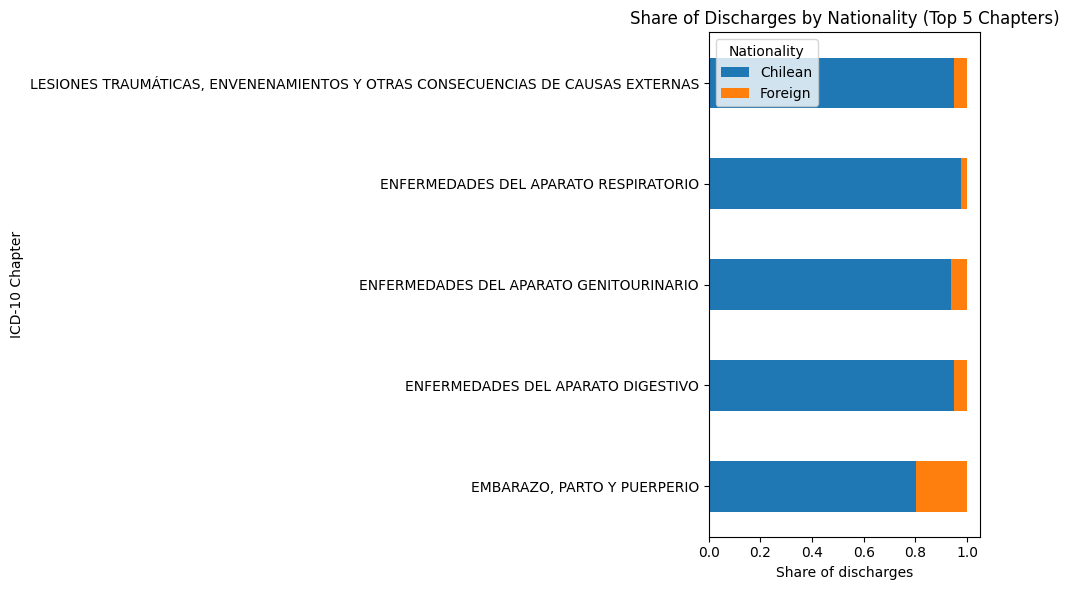

In [36]:
# --- Step 1: Keep only the top 5 chapters ---
top5_chapters = (
    grd_com["Capítulo"]
    .value_counts()
    .head(5)
    .index
)

df_top5 = grd_com[grd_com["Capítulo"].isin(top5_chapters)].copy()

# --- Step 2: Count discharges by chapter and nationality ---
counts = (
    df_top5
    .groupby(["Capítulo", "nat_group"])
    .size()
    .reset_index(name="count")
)

# --- Step 3: Compute shares within each chapter ---
counts["share"] = counts.groupby("Capítulo")["count"].transform(lambda x: x / x.sum())

# --- Step 4: Pivot table for plotting ---
pivot = counts.pivot(index="Capítulo", columns="nat_group", values="share").fillna(0)

# --- Step 5: Shorten chapter labels for readability ---
pivot = pivot.copy()
pivot.index = (
    pivot.index
    .str.replace(r"Cap\.\d+\s*", "", regex=True)
    .str.split("(").str[0]
    .str.strip()
)

# --- Step 6: Plot horizontal stacked bar chart ---
pivot.sort_index().plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Share of discharges")
plt.ylabel("ICD-10 Chapter")
plt.title("Share of Discharges by Nationality (Top 5 Chapters)")
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

The comparison of diagnostic chapters by nationality shows that Chilean patients account for the majority of hospital discharges across all major categories. However, differences emerge when analyzing the relative share of foreign patients.

In most chapters, such as respiratory, digestive, genitourinary, and injury-related conditions, foreign patients represent a relatively small proportion, which is consistent with their overall share of hospitalizations.

In contrast, Chapter 15 (Pregnancy, childbirth, and the puerperium) exhibits a substantially higher share of foreign patients, reaching close to 20%. This indicates a clear over-representation compared to their baseline participation.

When contextualized with the results from Tarea 1, where the foreign-born population represents a much smaller proportion of the total population, this pattern becomes particularly significant. It suggests that foreign patients are more represented in maternal and obstetric hospitalizations in the selected comunas.

Overall, the results highlight that while most hospitalization patterns are consistent across nationality groups, childbirth-related care stands out as a key area of difference.

### B.2 Length of Stay & Severity

#### B.2.1 Length of stay by nationality

To compare hospitalization patterns across nationality groups, the length of stay (LOS) is analyzed separately for Chilean and foreign patients. The mean and median LOS are computed for each group and presented in a summary table.

Additionally, the distribution of LOS is visualized using capped values (maximum of 30 days) to improve readability and reduce the influence of extreme outliers. This allows for a clearer comparison of typical hospitalization durations between groups.

LOS summary by nationality:


,nat_group,mean,median
0,Chilean,6.027963,3.0
1,Foreign,4.917179,3.0


<Figure size 800x500 with 0 Axes>

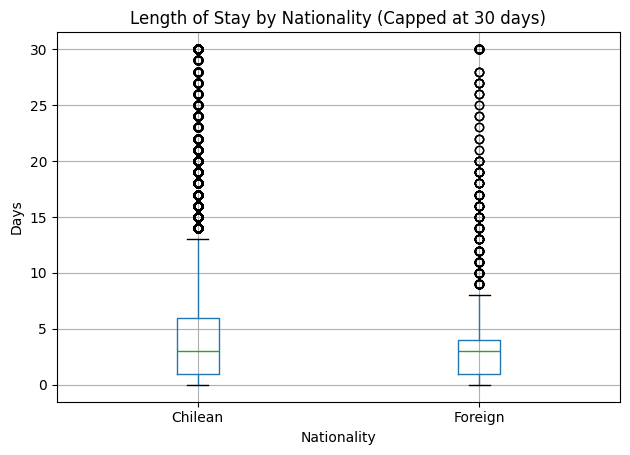

In [37]:
# --- Step 1: Summary table (mean & median) ---
los_summary = (
    grd_com
    .groupby("nat_group")["los"]
    .agg(["mean", "median"])
    .reset_index()
)

print("LOS summary by nationality:")
display(los_summary)

# --- Step 2: Cap LOS at 30 days for visualization ---
grd_com["los_capped"] = grd_com["los"].clip(upper=30)

# --- Step 3: Boxplot by nationality ---
plt.figure(figsize=(8, 5))

grd_com.boxplot(column="los_capped", by="nat_group")

plt.title("Length of Stay by Nationality (Capped at 30 days)")
plt.suptitle("")  # remove default title
plt.xlabel("Nationality")
plt.ylabel("Days")

plt.tight_layout()
plt.show()

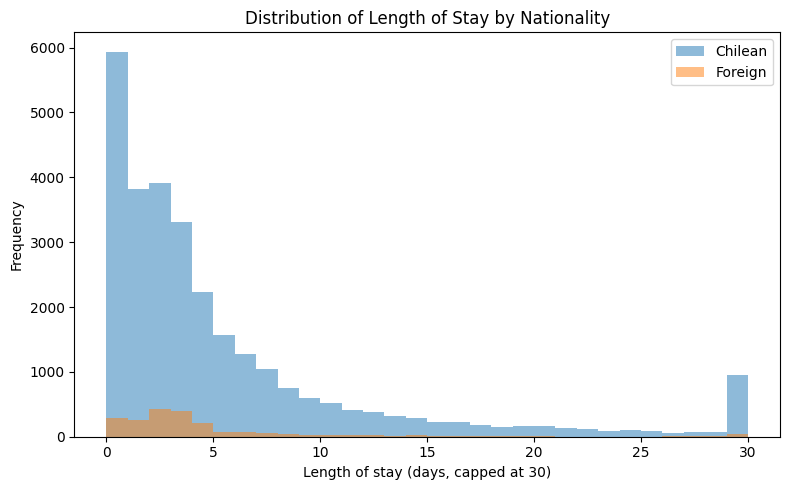

In [40]:
plt.figure(figsize=(8, 5))

# Chilean
plt.hist(
    grd_com.loc[grd_com["nat_group"] == "Chilean", "los_capped"],
    bins=30,
    alpha=0.5,
    label="Chilean"
)

# Foreign
plt.hist(
    grd_com.loc[grd_com["nat_group"] == "Foreign", "los_capped"],
    bins=30,
    alpha=0.5,
    label="Foreign"
)

plt.xlabel("Length of stay (days, capped at 30)")
plt.ylabel("Frequency")
plt.title("Distribution of Length of Stay by Nationality")

plt.legend()
plt.tight_layout()
plt.show()

The comparison of length of stay (LOS) by nationality shows that hospitalization durations are broadly similar across groups, with only minor differences.

Chilean patients have a mean LOS of approximately 6.03 days and a median of 3 days, while foreign patients have a slightly lower mean LOS of 4.92 days and the same median of 3 days. This indicates that typical hospital stays are comparable between groups, although Chilean patients tend to experience slightly longer stays on average.

The boxplot reveals a similar central distribution and spread for both groups, with comparable interquartile ranges and a similar presence of longer stays (outliers). This suggests that the overall structure of hospitalization duration is consistent across nationality groups.

The histogram further supports this conclusion, showing that both distributions are highly concentrated in shorter stays, particularly between 0 and 5 days, and exhibit a right-skewed shape with a long tail of longer hospitalizations. While Chilean patients show a slightly higher frequency of longer stays, the overall patterns remain very similar.

The small difference in mean LOS may reflect variations in case mix or severity, but overall hospitalization patterns appear consistent across nationality groups.

#### B.2.2 Severity distribution

To compare the severity of hospitalizations across nationality groups, the variable `IR_29301_SEVERIDAD` is used. This variable classifies cases into four levels: no severity, minor, moderate, and major.

Using the official labels provided in the GRD reference table, the severity distribution is computed and visualized as a bar chart split by nationality. This allows a direct comparison of the relative severity profile of hospital discharges for Chilean and foreign patients.

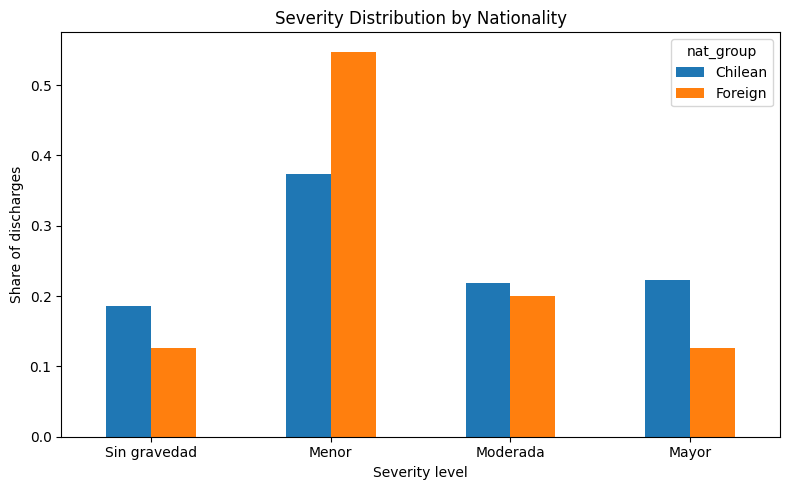

In [41]:
# --- Step 1: Load severity labels ---
sev_labels = pd.read_excel(
    "TablasMaestrasBasesGRD.xlsx",
    sheet_name="Severidad GRD"
)

# --- Step 2: Rename columns using the actual Excel structure ---
sev_labels = sev_labels.rename(columns={
    "Severidad": "severity",
    "Unnamed: 1": "severity_label"
})

# Keep only the required columns
sev_labels = sev_labels[["severity", "severity_label"]].copy()

# Convert severity codes to numeric
sev_labels["severity"] = pd.to_numeric(sev_labels["severity"], errors="coerce")

# --- Step 3: Clean severity variable in GRD ---
grd_com["severity"] = pd.to_numeric(grd_com["IR_29301_SEVERIDAD"], errors="coerce")

# --- Step 4: Merge GRD with severity labels ---
grd_com = grd_com.merge(
    sev_labels,
    on="severity",
    how="left"
)

# --- Step 5: Compute severity distribution by nationality ---
sev_dist = (
    grd_com
    .groupby(["severity_label", "nat_group"])
    .size()
    .reset_index(name="count")
)

# Convert counts to shares within each nationality group
sev_dist["share"] = sev_dist.groupby("nat_group")["count"].transform(lambda x: x / x.sum())

# --- Step 6: Pivot for plotting ---
pivot_sev = sev_dist.pivot(index="severity_label", columns="nat_group", values="share").fillna(0)

# Order categories logically
severity_order = ["Sin gravedad", "Menor", "Moderada", "Mayor"]
pivot_sev = pivot_sev.reindex(severity_order)

# --- Step 7: Plot ---
pivot_sev.plot(kind="bar", figsize=(8, 5))

plt.ylabel("Share of discharges")
plt.xlabel("Severity level")
plt.title("Severity Distribution by Nationality")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The severity distribution shows that most hospital discharges fall within the lower and moderate severity categories for both nationality groups, although some differences can be observed.

Foreign patients are more concentrated in the “Menor” (minor severity) category, accounting for a larger share compared to Chilean patients. In contrast, Chilean patients exhibit higher shares in the “Sin gravedad” (no severity), “Moderada”, and especially “Mayor” (major severity) categories.

This suggests that foreign patients tend to have a slightly lower severity distribution, while Chilean patients are more likely to experience moderate to high severity cases. The difference is particularly noticeable in the “Mayor” category, where Chilean patients represent a substantially larger share.

Overall, while both groups are dominated by lower-severity hospitalizations, the results indicate a slightly higher concentration of more severe cases among Chilean patients.

#### B.2.3 Discharge type

To analyze discharge outcomes, the variable `TIPOALTA` is used, which captures the type of discharge (e.g., home discharge, death, transfer).

The distribution of discharge types is first explored to understand the most common outcomes. Additionally, the in-hospital mortality rate is computed as the share of discharges where `TIPOALTA == "FALLECIDO"`, and compared across nationality groups.

In [42]:
# --- Step 1: Distribution of discharge types ---
discharge_dist = (
    grd_com["TIPOALTA"]
    .value_counts(normalize=True)
    .reset_index()
)

discharge_dist.columns = ["tipo_alta", "share"]

print("Discharge distribution:")
display(discharge_dist)

# --- Step 2: Mortality rate by nationality ---
grd_com["is_dead"] = (grd_com["TIPOALTA"] == "FALLECIDO").astype(int)

mortality = (
    grd_com
    .groupby("nat_group")["is_dead"]
    .mean()
    .reset_index()
)

mortality.columns = ["nat_group", "mortality_rate"]

print("In-hospital mortality rate by nationality:")
display(mortality)

Discharge distribution:


,tipo_alta,share
0,DOMICILIO,0.902055
1,HOSPITALIZACIÓN DOMICILIARIA,0.032066
2,FALLECIDO,0.028469
3,ALTA VOLUNTARIA,0.013288
4,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,0.010273
5,DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,0.004221
6,FUGA DEL PACIENTE,0.003265
7,DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,0.003015
8,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",0.002724
9,DERIVACIÓN INST. PRIVADA (VOLUNTARIO),0.000624


In-hospital mortality rate by nationality:


,nat_group,mortality_rate
0,Chilean,0.029794
1,Foreign,0.009960


The distribution of discharge types shows that the vast majority of patients are discharged to home (“DOMICILIO”), accounting for over 90% of all cases. Other outcomes, such as home hospitalization, voluntary discharge, and transfers to other institutions, represent relatively small shares. In-hospital deaths (“FALLECIDO”) account for approximately 2.8% of total discharges.

The in-hospital mortality rate differs notably by nationality. Chilean patients have a mortality rate of approximately 2.98%, while foreign patients have a substantially lower rate of 1.00%.

This indicates that Chilean patients experience a higher likelihood of in-hospital death compared to foreign patients. This difference may reflect variations in case severity, age distribution, or underlying health conditions, rather than differences in care itself.

Overall, while discharge outcomes are dominated by home discharges for both groups, the mortality gap suggests that Chilean patients tend to present with more severe or complex cases.

### B.3 Spatial View 

#### B.3.1 Choropleth: hospitalization rate by comuna

To analyze spatial differences in hospitalization patterns, a crude hospitalization rate is computed for each comuna, defined as total discharges per 10,000 inhabitants.

This rate is visualized using a choropleth map, allowing for comparison across comunas while accounting for population size.

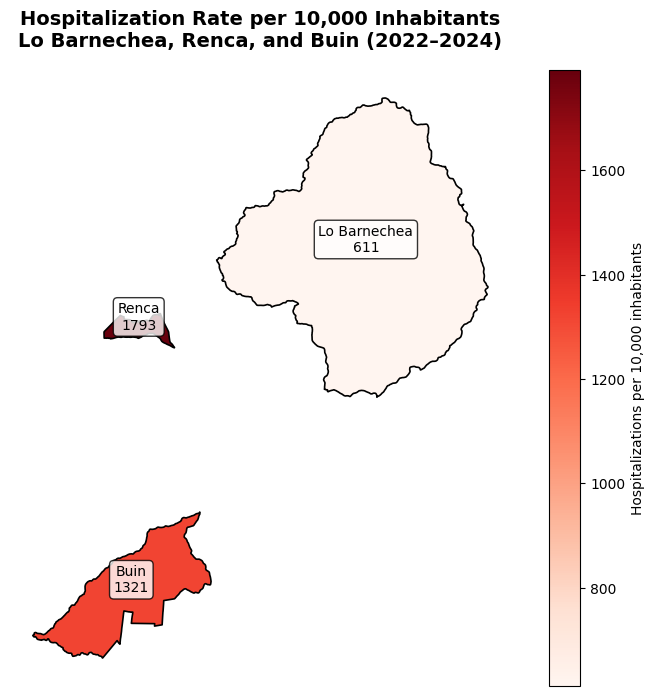

In [44]:
import geopandas as gpd
# --- Step 1: Define assigned comuna codes as strings ---
my_comunas_str = ["13115", "13128", "13402"]

# --- Step 2: Build comuna code mapping from Tarea 1 summary ---
t1 = pd.read_csv("output/tarea1_comuna_summary.csv")

code_map = (
    t1[["codigo_comuna", "nombre_comuna", "pop_total"]]
    .drop_duplicates()
    .copy()
)

code_map["codigo_comuna"] = code_map["codigo_comuna"].astype(int).astype(str)

# Standardize names to match GRD
code_map["nombre_comuna_clean"] = (
    code_map["nombre_comuna"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Dictionary: uppercase comuna name -> comuna code
comuna_mapping = dict(zip(code_map["nombre_comuna_clean"], code_map["codigo_comuna"]))

# Dictionary: comuna code -> population
pop_dict = dict(zip(code_map["codigo_comuna"], code_map["pop_total"]))

# --- Step 3: Compute discharge counts by comuna in GRD ---
counts = grd_com.groupby("COMUNA").size()

# --- Step 4: Compute hospitalization rate per 10,000 inhabitants ---
rates = {
    comuna_mapping[name]: counts.get(name, 0) / pop_dict[comuna_mapping[name]] * 10000
    for name in my_comuna_names
}

# --- Step 5: Load shapefile ---
gdf = gpd.read_file("comunas.shp")

# --- Step 6: Keep only the assigned comunas ---
gdf["cod_comuna"] = gdf["cod_comuna"].astype(str)
gdf = gdf[gdf["cod_comuna"].isin(my_comunas_str)].copy()

# --- Step 7: Add hospitalization rates ---
gdf["rate"] = gdf["cod_comuna"].map(rates)

# --- Step 8: Plot choropleth map ---
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    column="rate",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=1.2,
    ax=ax,
    legend_kwds={"label": "Hospitalizations per 10,000 inhabitants"}
)

ax.set_title(
    "Hospitalization Rate per 10,000 Inhabitants\nLo Barnechea, Renca, and Buin (2022–2024)",
    fontsize=14,
    fontweight="bold"
)

ax.axis("off")

# --- Step 9: Add labels with comuna name and rate ---
for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        f"{row['Comuna']}\n{row['rate']:.0f}",
        (c.x, c.y),
        ha="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
    )

# --- Step 10: Save figure ---
os.makedirs("output", exist_ok=True)
plt.savefig("output/tarea2_grd_map.png", dpi=300, bbox_inches="tight")

plt.show()

The choropleth map highlights clear differences in hospitalization rates across the selected comunas. Renca presents the highest hospitalization rate, with approximately 1,793 discharges per 10,000 inhabitants, followed by Buin with around 1,321. In contrast, Lo Barnechea shows a substantially lower rate of about 611.

These differences persist after adjusting for population size, indicating that hospitalization burden varies across comunas even after standardizing by population.

Renca stands out as the comuna with the highest hospitalization burden, while Lo Barnechea exhibits the lowest, with Buin positioned in between.

### B.4 Comuna-Level GRD Summary Table

In this final step, a comuna-level summary table is built to consolidate the main GRD indicators derived throughout the analysis. The table includes total discharges, nationality breakdown, mean length of stay, mean severity, in-hospital mortality, top diagnostic chapters, and crude hospitalization rates.

This summary table is designed to support both the interpretation of the current assignment and the integration of GRD indicators with the Census-based comuna summary in Tarea 3.

In [46]:
# --- Step 1: Build comuna-level GRD summary function ---
def build_grd_summary(df):
    return pd.Series({
        "grd_total": len(df),
        "grd_chilean": (df["nat_group"] == "Chilean").sum(),
        "grd_foreign": (df["nat_group"] == "Foreign").sum(),
        "grd_pct_foreign": (df["nat_group"] == "Foreign").mean() * 100,  # <-- CORREGIDO
        "grd_mean_los": df["los"].mean(),
        "grd_mean_los_chilean": df.loc[df["nat_group"] == "Chilean", "los"].mean(),
        "grd_mean_los_foreign": df.loc[df["nat_group"] == "Foreign", "los"].mean(),
        "grd_mean_severity": pd.to_numeric(df["IR_29301_SEVERIDAD"], errors="coerce").mean(),
        "grd_mortality_rate": (df["TIPOALTA"] == "FALLECIDO").mean(),
        "grd_top3_chapters": ", ".join(df["Capítulo"].dropna().value_counts().head(3).index.astype(str))
    })

# --- Step 2: Compute summary by comuna ---
grd_summary = (
    grd_com
    .groupby("COMUNA")
    .apply(build_grd_summary)
    .reset_index()
)

# --- Step 3: Load Tarea 1 summary to recover comuna code and population ---
t1 = pd.read_csv("output/tarea1_comuna_summary.csv")

# Standardize comuna names for merging
grd_summary["COMUNA_clean"] = (
    grd_summary["COMUNA"]
    .astype(str)
    .str.upper()
    .str.strip()
)

t1["nombre_comuna_clean"] = (
    t1["nombre_comuna"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# --- Step 4: Merge with Tarea 1 summary ---
grd_summary = grd_summary.merge(
    t1[["codigo_comuna", "nombre_comuna", "pop_total", "nombre_comuna_clean"]],
    left_on="COMUNA_clean",
    right_on="nombre_comuna_clean",
    how="left"
)

# --- Step 5: Compute crude hospitalization rate per 10,000 inhabitants ---
grd_summary["grd_rate_per_10k"] = (
    grd_summary["grd_total"] / grd_summary["pop_total"]
) * 10000

# --- Step 6: Keep only the required columns in the requested order ---
grd_summary = grd_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "grd_total",
        "grd_chilean",
        "grd_foreign",
        "grd_pct_foreign",
        "grd_mean_los",
        "grd_mean_los_chilean",
        "grd_mean_los_foreign",
        "grd_mean_severity",
        "grd_mortality_rate",
        "grd_top3_chapters",
        "grd_rate_per_10k"
    ]
].copy()

# --- Step 7: Optional formatting ---
grd_summary["codigo_comuna"] = grd_summary["codigo_comuna"].astype("Int64")
grd_summary["grd_pct_foreign"] = grd_summary["grd_pct_foreign"].round(2)  # <-- NUEVO

# --- Step 8: Save and display ---
grd_summary.to_csv("output/tarea2_grd_summary.csv", index=False)

print("GRD summary table:")
display(grd_summary)

GRD summary table:


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13402,Buin,15457,14669,788,5.10,5.576291,5.603302,5.086142,1.488646,0.029566,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1321.461242
1,13115,Lo Barnechea,6883,6204,679,9.86,5.166742,5.239609,4.483568,1.425977,0.017725,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",611.170307
2,13128,Renca,25748,24002,1746,6.78,6.392185,6.495590,4.999133,1.464696,0.030682,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1792.761555


The comuna-level GRD summary table consolidates the main hospitalization indicators for Buin, Lo Barnechea, and Renca, including total discharges, nationality composition, length of stay, severity, mortality, and crude hospitalization rates.

Clear differences emerge across comunas. Renca presents the highest hospitalization burden, with both the largest number of discharges and the highest rate per 10,000 inhabitants, while Lo Barnechea shows the lowest hospitalization rate. Buin lies in an intermediate position.

In terms of nationality composition, Lo Barnechea exhibits the highest share of foreign patients (approximately 9.9%), followed by Renca and Buin. Despite this, foreign patients tend to have slightly shorter lengths of stay across all comunas, consistent with previous findings.

Regarding clinical outcomes, Renca shows both the highest average length of stay and the highest in-hospital mortality rate, indicating a comparatively higher hospitalization burden. In contrast, Lo Barnechea has the lowest mortality rate and lower severity levels on average.

Overall, the summary table highlights meaningful variation in hospitalization patterns across comunas, reinforcing the spatial and demographic differences identified throughout the analysis. These indicators provide a comprehensive overview of local healthcare demand and will serve as key inputs for further analysis in Tarea 3.